In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

from langchain_huggingface import HuggingFaceEndpoint
from langchain_huggingface.chat_models import ChatHuggingFace
from dotenv import load_dotenv
import os

/home/aminul/anaconda3/envs/spector/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
load_dotenv()

# Initialize HuggingFace LLM
llm = HuggingFaceEndpoint(
    repo_id="openai/gpt-oss-20b",
    task="text-generation",
    huggingfacehub_api_token=os.getenv("HUGGINGFACE_API_KEY")
)

model = ChatHuggingFace(llm=llm)

In [4]:
class BlogState(TypedDict):
    runs: int
    balls : int
    fuors : int
    sixes : int
    
    strike_rate : float
    ball_per_boundary : float
    boundary_percentage : float

In [5]:
def calculate_sr(state: BlogState) -> BlogState:
    state['strike_rate'] = (state['runs'] / state['balls']) * 100
    return {'strike_rate':state['strike_rate']}

def calculate_bpb(state: BlogState) -> BlogState:
    total_boundaries = state['fuors'] + state['sixes']
    state['ball_per_boundary'] = state['balls'] / total_boundaries if total_boundaries > 0 else float('inf')
    return {'ball_per_boundary':state['ball_per_boundary']}

def calculate_bpct(state: BlogState) -> BlogState:
    total_boundaries = state['fuors'] + state['sixes']
    state['boundary_percentage'] = (total_boundaries / state['balls']) * 100 if state['balls'] > 0 else 0
    return {'boundary_percentage':state['boundary_percentage']}

def final_report(state: BlogState) -> BlogState:
    report = (
        f"Final Batting Report:\n"
        f"Runs: {state['runs']}\n"
        f"Balls: {state['balls']}\n"
        f"Fours: {state['fuors']}\n"
        f"Sixes: {state['sixes']}\n"
        f"Strike Rate: {state['strike_rate']:.2f}\n"
        f"Balls per Boundary: {state['ball_per_boundary']:.2f}\n"
        f"Boundary Percentage: {state['boundary_percentage']:.2f}%\n"
    )
    return state

In [6]:
graph = StateGraph(BlogState)

# Nodes
graph.add_node('calculate_sr', calculate_sr)
graph.add_node('calculate_bpb', calculate_bpb)
graph.add_node('calculate_bpct', calculate_bpct)
graph.add_node('final_report', final_report)

#  Edges
graph.add_edge(START, 'calculate_sr')
graph.add_edge(START, 'calculate_bpb')
graph.add_edge(START, 'calculate_bpct')

graph.add_edge('calculate_sr', 'final_report')
graph.add_edge('calculate_bpb', 'final_report')
graph.add_edge('calculate_bpct', 'final_report')
graph.add_edge('final_report', END)


workflow = graph.compile()

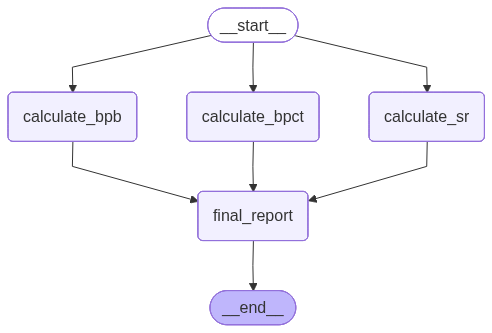

In [7]:
workflow

In [8]:
initial_state = {
    'runs': 150,
    'balls': 120,
    'fuors': 15,
    'sixes': 5,
}

workflow.invoke(initial_state)

{'runs': 150,
 'balls': 120,
 'fuors': 15,
 'sixes': 5,
 'strike_rate': 125.0,
 'ball_per_boundary': 6.0,
 'boundary_percentage': 16.666666666666664}